In [ ]:
from pyLensLib.piemd import piemd
from astropy.cosmology import FlatLambdaCDM
import numpy as np
co = FlatLambdaCDM(H0=70, Om0=0.3)
import matplotlib.pyplot as plt

# create a PIEMD lens model instance
kwargs_piemd = {'zl': 0.5,
              'zs': 2.0,
              'sigma0': 1000.0,
              'q': 1.0,
              'pa': -np.pi / 4.0,
              'theta_c': 0.01,
              'theta_t': 10.0,
              'x1': 0.0,
              'x2': 0.0}

lm = piemd(co,**kwargs_piemd)

r = np.linspace(0.01, 1000.0, 100)
rho_piemd = lm.density(r)

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(r,rho_piemd)
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()


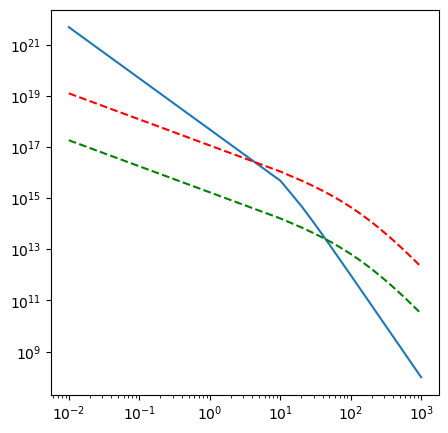

In [2]:
from pyLensLib.nfwell import nfwell

# create a fake nfw lens model instance
kwargs_nfw =  {'zl': 0.2, 'zs': 2.0, 'mass': 1e15, 'conc': 4.0, 'x1': 0.0, 'x2': 0.0, 'q': 1.0, 'pa': 0.0}
ne = nfwell(co,**kwargs_nfw)

# now recompute the parameters of the NFW model by fitting the PIEMD model

kwargs_fit = {'rs_in': 1000.0, 'rs_min': 1.0, 'rs_max': 1300.0, 'rhos_in':1e15, 'rhos_min':1e2, 'rhos_max':1e40}
rho_ini = ne.density(r)
ne.fit2piemd(lm,**kwargs_fit)
rho_fit = ne.density(r)

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(r,rho_piemd)
ax.plot(r,rho_ini,ls='--',color='red')
ax.plot(r,rho_fit,ls='--',color='green')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()


In [3]:
print (ne.rs, ne.rhos)

1000.0 12762233553214.764


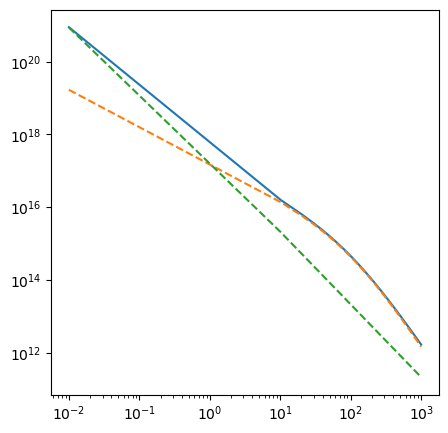

In [13]:
from pyLensLib.compositeModel import compositeModel
from pyLensLib.sie import sie

# create a NFW lens model instance
kwargs_nfw =  {'zl': 0.2, 'mass': 8e14, 'conc': 5.3}
ne = nfwell(co,**kwargs_nfw)

# create a SIE lens model instance
kwargs_sie =  {'zl': 0.2,
              'sigma0': 250.0,
              'theta_c': 0.012}

sl = sie(co,**kwargs_sie)
cm0 = compositeModel(co,[ne,sl])

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(r,cm0.density(r))
ax.plot(r,ne.density(r),'--')
ax.plot(r,sl.density(r),'--')
ax.set_xscale('log')
ax.set_yscale('log')


# Testing the fitting procedure

In this first test, we will fit a compoosite model made of a NFW and SIE lenses with another similar composite model.

[[Fit Statistics]]
    # fitting method   = Nelder-Mead
    # function evals   = 545
    # data points      = 100
    # variables        = 4
    chi-square         = 5.2510e-20
    reduced chi-square = 5.4698e-22
    Akaike info crit   = -4891.84515
    Bayesian info crit = -4881.42447
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    mass:     14.9031701 (init = 10)
    conc:     5.29982737 (init = 8)
    sigma0:   2.66512529 (init = 1.90309)
    theta_c: -1.92073688 (init = -1)
    rt:       2 (fixed)


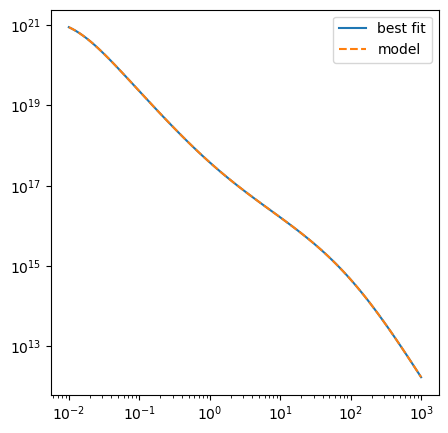

In [160]:

import lmfit
rmin = 0.01
rmax = 10000.0

# initial setup
kwargs_fit = {'mass_in': 1e10, 'mass_fit': True, 'mass_min': 1e8, 'mass_max': 1e17,
              'conc_in': 8.0, 'conc_fit': True, 'conc_min': 0.001, 'conc_max': 1000.0,
              'sigma0_in': 80.0, 'sigma0_fit': True,'sigma0_min': 1.0, 'sigma0_max': 1000.0,
              'theta_c_in': 0.1, 'theta_c_fit': True,'theta_c_min': 0.00001, 'theta_c_max': 10.0,
              'rt_in': 0.1, 'rt_fit': False, 'rt_min': 100.0, 'rt_max': 10000.0}

def truncation(r,rt):
    return 1.0/(1.0+r**2/rt**2)**2

# 
def fit_comp_to_model(model,rmin,rmax,**kwargs_fit):
    r = np.logspace(np.log10(rmin),np.log10(rmax),100)
    p = lmfit.Parameters()
    p.add_many(('mass', np.log10(kwargs_fit['mass_in']), kwargs_fit['mass_fit'], 
                np.log10(kwargs_fit['mass_min']), np.log10(kwargs_fit['mass_max'])),
               ('conc', kwargs_fit['conc_in'], kwargs_fit['conc_fit'], 
                kwargs_fit['conc_min'], kwargs_fit['conc_max']),
               ('sigma0', np.log10(kwargs_fit['sigma0_in']), kwargs_fit['sigma0_fit'], 
                np.log10(kwargs_fit['sigma0_min']),  np.log10(kwargs_fit['sigma0_max'])),
               ('theta_c', np.log10(kwargs_fit['theta_c_in']), kwargs_fit['theta_c_fit'],
                np.log10(kwargs_fit['theta_c_min']),  np.log10(kwargs_fit['theta_c_max'])),
               ('rt', np.log10(kwargs_fit['rt_in']), kwargs_fit['rt_fit'],
                np.log10(kwargs_fit['rt_min']), np.log10(kwargs_fit['rt_max'])))
    
    def cost_function(p):
        v = p.valuesdict()
        ne = nfwell(co, zl=0.2, mass=10 ** v['mass'], conc=v['conc'])
        sl = sie(co, zl=0.5, sigma0=10 ** v['sigma0'], theta_c=10 ** v['theta_c'])
        if kwargs_fit['rt_fit']:
            density = ne.density(r)*truncation(r,10**v['rt']) + sl.density(r)*truncation(r,10**(v['rt']/4.0))
        else:
            density = ne.density(r) + sl.density(r)
        #cm = compositeModel(co, [ne, sl])
        #density = ne.density(r)*(1.0/(1.0+r**2/(10**p['rt'])**2))**2 + sl.density(r)
        #cost = (np.log10(cm.density(r))-np.log10(model.density(r)))**2/np.log10(model.density(r))**2
        cost = (np.log10(density)-np.log10(model.density(r)))**2/np.log10(model.density(r))**2
        return cost

    mini = lmfit.Minimizer(cost_function, p)
    mi = mini.minimize(method='Nelder')  # residual, p, method='Nelder')
    lmfit.report_fit(mi)

    return mi

mi = fit_comp_to_model(cm0,rmin=rmin,rmax=rmax,**kwargs_fit)

# create a composite model with the best fit parameters
ne = nfwell(co, zl=0.2, mass=10 ** mi.params['mass'], conc=mi.params['conc'])
sl = sie(co, zl=0.5, sigma0=10 ** mi.params['sigma0'], theta_c=10 ** mi.params['theta_c'])
cm = compositeModel(co, [ne, sl])

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(r,cm.density(r),label='best fit')
ax.plot(r,cm0.density(r),'--',label='model')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

Now we perform the same fit to a PIEMD model

[[Fit Statistics]]
    # fitting method   = Nelder-Mead
    # function evals   = 268
    # data points      = 100
    # variables        = 4
    chi-square         = 1.2898e-05
    reduced chi-square = 1.3435e-07
    Akaike info crit   = -1578.36305
    Bayesian info crit = -1567.94237
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    mass:     12.2979547 (init = 10)
    conc:     156.747250 (init = 8)
    sigma0:   1.46150342 (init = 2.39794)
    theta_c: -4 (fixed)
    rt:       1.99998633 (init = -1)
mass: 1985887608838.5469 sigma0 28.940326072116278 conc <Parameter 'conc', value=156.74725004368872, bounds=[0.001:1000.0]> theta_c 0.0001 rt 99.99685240832079


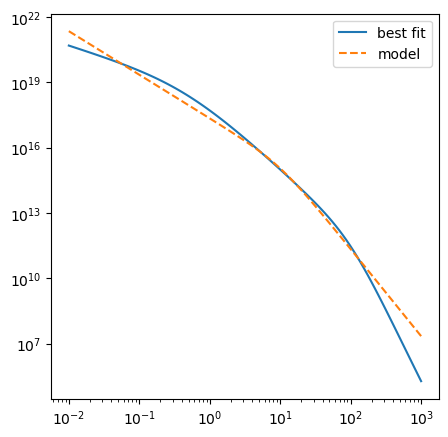

In [161]:
# initial setup
kwargs_fit = {'mass_in': 1e10, 'mass_fit': True, 'mass_min': 1e8, 'mass_max': 1e17,
              'conc_in': 8.0, 'conc_fit': True, 'conc_min': 0.001, 'conc_max': 1000.0,
              'sigma0_in': 250.0, 'sigma0_fit': True,'sigma0_min': 1.0, 'sigma0_max': 1000.0,
              'theta_c_in': 0.0001, 'theta_c_fit': False,'theta_c_min': 0.00001, 'theta_c_max': 10.0,
              'rt_in': 0.1, 'rt_fit': True, 'rt_min': 0.01, 'rt_max': 100.0}

# create a PIEMD lens model instance
kwargs_piemd = {'zl': 0.2,
              'zs': 2.0,
              'sigma0': 254.0,
              'q': 1.0,
              'pa': 0.0,
              'theta_c': 0.0001,
              'theta_t': 10.0,
              'x1': 0.0,
              'x2': 0.0}

lm = piemd(co,**kwargs_piemd)

mi = fit_comp_to_model(lm,rmin=0.01,rmax=200.0,**kwargs_fit)

# create a composite model with the best fit parameters
ne = nfwell(co, zl=0.2, mass=10 ** mi.params['mass'], conc=mi.params['conc'])
sl = sie(co, zl=0.5, sigma0=10 ** mi.params['sigma0'], theta_c=10 ** mi.params['theta_c'])
cm = compositeModel(co, [ne, sl])

r = np.logspace(np.log10(0.01),np.log10(1000),100)
fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(r,(ne.density(r) + sl.density(r))*truncation(r,10**mi.params['rt']),label='best fit')
ax.plot(r,lm.density(r),'--',label='model')
#ax.plot(r,ne.density(r)*truncation(r,10**mi.params['rt']),':',color='violet',label='NFW',lw=5)
#ax.plot(r,sl.density(r)*truncation(r,10**mi.params['rt']),':',color='red',label='SIE')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

print ('mass:',10 ** mi.params['mass'], 'sigma0', 10 ** mi.params['sigma0'], 'conc', mi.params['conc'], 'theta_c', 10 ** mi.params['theta_c'], 'rt', 10 ** mi.params['rt'])


# Fitting galaxies from a lenstool best.par file

In this test, we will fit a composite model to all galaxies from a lenstool best.par file.

Galaxy: 4229
[[Fit Statistics]]
    # fitting method   = Nelder-Mead
    # function evals   = 292
    # data points      = 100
    # variables        = 4
    chi-square         = 8.1274e-04
    reduced chi-square = 8.4660e-06
    Akaike info crit   = -1164.02737
    Bayesian info crit = -1153.60669
##  Warning: uncertainties could not be estimated:
    this fitting method does not natively calculate uncertainties
    and numdifftools is not installed for lmfit to do this. Use
    `pip install numdifftools` for lmfit to estimate uncertainties
    with this fitting method.
[[Variables]]
    mass:     13.1061146 (init = 11.52943)
    conc:     5.20264796 (init = 8)
    sigma0:   1.64288080 (init = 2.358066)
    theta_c: -2.295163 (fixed)
    rt:       0.69005593 (init = 0.1955039)
0.005068
mass: 12767755394954.807 sigma0 43.942098947544466 conc <Parameter 'conc', value=5.20264795532025, bounds=[0.001:1000.0]> theta_c 0.005067999999999998 rt 4.898419039575665
Galaxy: 4428
[[Fit Statistics]

TypeError: __array__() takes 1 positional argument but 2 were given

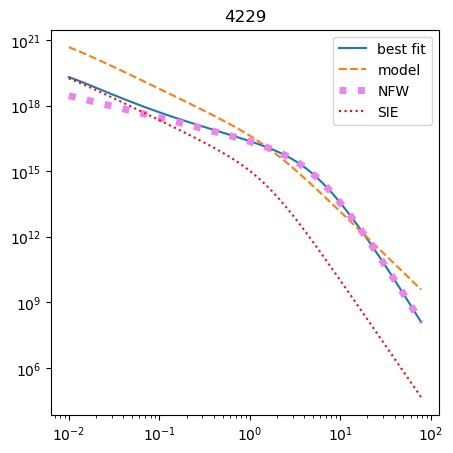

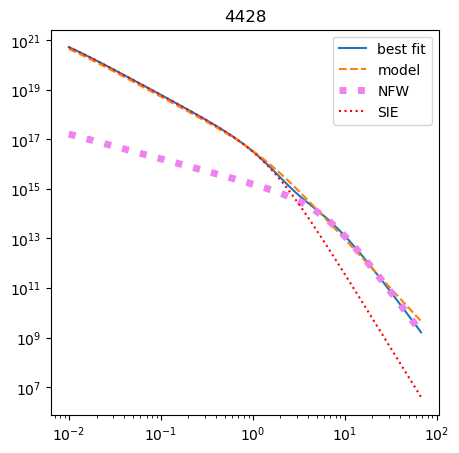

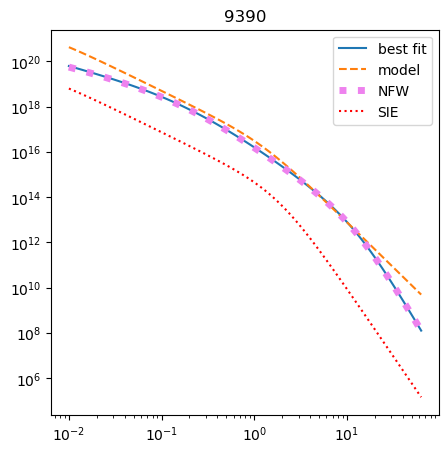

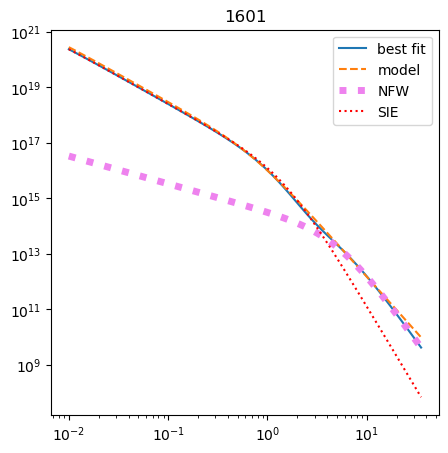

In [166]:
import pyLensLib.lenstool as lst
df = lst.getClMembers('/Users/maxmen3/stiva/pietro_models/M1206pl.par')

# for each galaxy in the df, we will fit a composite model and save the best fit parameters in a csv file
file_to_save = 'best_fit.csv'
mass_list = []
sigma0_list = []
conc_list = []
theta_c_list = []
rt_list = []

for i in range(6,10): #range(len(df)):
    print ('Galaxy:',df.gal_id[i])
    # create a PIEMD lens model instance
    kwargs_piemd = {'zl': df.z_lens[i],
              'zs': 2.0,
              'sigma0': df.v_disp[i]*np.sqrt(3.0/2.0),
              'q': 1.0,
              'pa': 0.0,
              'theta_c': df.core_radius[i],
              'theta_t': df.cut_radius[i],
              'x1': 0.0,
              'x2': 0.0}

    lm = piemd(co,**kwargs_piemd)
    kwargs_fit = {'mass_in': lm.mass(), 'mass_fit': True, 'mass_min': lm.mass()*0.01, 'mass_max': lm.mass()*100.,
              'conc_in': 8.0, 'conc_fit': True, 'conc_min': 0.001, 'conc_max': 1000.0,
              'sigma0_in': df.v_disp[i]*np.sqrt(3.0/2.0), 'sigma0_fit': True,'sigma0_min': df.v_disp[i]*np.sqrt(3.0/2.0)/10., 'sigma0_max': df.v_disp[i]*np.sqrt(3.0/2.0)*10,
              'theta_c_in': df.core_radius[i], 'theta_c_fit': False,'theta_c_min': df.core_radius[i]*0.1, 'theta_c_max': df.core_radius[i]*10.0,
              'rt_in': df.cut_radius[i], 'rt_fit': True, 'rt_min': df.cut_radius[i]/10, 'rt_max': df.cut_radius[i]*10.0}
    mi = fit_comp_to_model(lm,rmin=0.01,rmax=df.cut_radius[i]*50.0,**kwargs_fit)
    
    print (df.core_radius[i])
    
    print ('mass:',10 ** mi.params['mass'], 'sigma0', 10 ** mi.params['sigma0'], 'conc', mi.params['conc'], 'theta_c', 10 ** mi.params['theta_c'], 'rt', 10 ** mi.params['rt'])
    
    mass_list.append(10 ** mi.params['mass'])
    sigma0_list.append(10 ** mi.params['sigma0'])
    conc_list.append(mi.params['conc'])
    theta_c_list.append(10 ** mi.params['theta_c'])
    rt_list.append(10 ** mi.params['rt'])
    
    ne = nfwell(co, zl=df.z_lens[i], mass=10 ** mi.params['mass'], conc=mi.params['conc'])
    sl = sie(co, zl=df.z_lens[i], sigma0=10 ** mi.params['sigma0'], theta_c=10 ** mi.params['theta_c'])
    
    r = np.logspace(np.log10(0.01),np.log10(df.cut_radius[i]*50.0),100)
    fig,ax = plt.subplots(1,1,figsize=(5,5))
    ax.plot(r,ne.density(r)*truncation(r,10**mi.params['rt']) + sl.density(r)*truncation(r,10**mi.params['rt']/4.0),label='best fit')
    ax.plot(r,lm.density(r),'--',label='model')
    ax.plot(r,ne.density(r)*truncation(r,10**mi.params['rt']),':',color='violet',label='NFW',lw=5)
    ax.plot(r,sl.density(r)*truncation(r,10**(mi.params['rt']/4.0)),':',color='red',label='SIE')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(df.gal_id[i])
    ax.legend()
    
# save the results in a csv file
import pandas as pd
df = pd.DataFrame({'mass':mass_list,'sigma0':sigma0_list,'conc':conc_list,'theta_c':theta_c_list,'rt':rt_list})
df.to_csv(file_to_save)


In [122]:
df

,gal_id,x_centre,y_centre,ellipticite,angle_pos,core_radius,core_radius_kpc,cut_radius,cut_radius_kpc,v_disp,z_lens
0,O1,-1.400476,0.141944,0.715715,19.755776,6.114535,34.719224,2000.000000,11356.292472,748.960488,0.439
1,O2,9.198743,3.629942,0.462472,116.686543,13.474236,76.508682,2000.000000,11356.292472,662.942555,0.439
2,O3,-28.873807,-6.833916,0.330616,-25.157143,12.318005,69.943434,2000.000000,11356.292472,501.277583,0.439
3,5,3.106646,-6.343505,0.119944,-0.714455,63.285763,359.345818,403.054272,2288.601097,452.228879,0.439
4,6,-13.499338,-7.240913,0.495775,-113.570548,40.528992,230.129543,43.935994,249.474997,342.304761,0.439
...,...,...,...,...,...,...,...,...,...,...,...
259,8031,-20.998100,57.738240,0.000000,0.000000,0.000448,0.002544,0.070665,0.401245,47.844858,0.439
260,3443,45.472344,-28.114920,0.000000,0.000000,0.000447,0.002535,0.070354,0.399478,47.752370,0.439
261,9689,29.204802,12.015000,0.000000,0.000000,0.000443,0.002514,0.069608,0.395246,47.529902,0.439
262,9589,33.169762,14.840640,0.000000,0.000000,0.000438,0.002486,0.068612,0.389588,47.230422,0.439


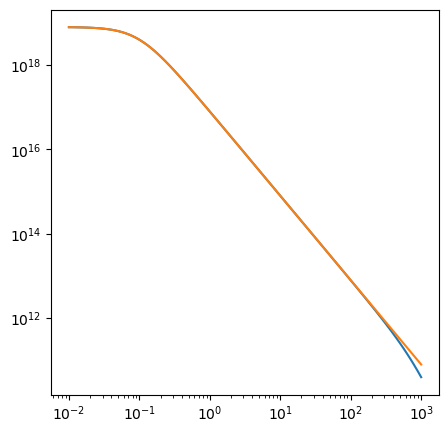

In [147]:
kwargs_piemd = {'zl': 0.4,
              'zs': 2.0,
              'sigma0': 250,
              'q': 1.0,
              'pa': 0.0,
              'theta_c': 0.1,
              'theta_t': 1000,
              'x1': 0.0,
              'x2': 0.0}
lm = piemd(co,**kwargs_piemd)

kwargs_sie = {'zl': 0.4,
              'zs': 2.0,
              'sigma0': 250,
              'q': 1.0,
              'pa': 0.0,
              'theta_c': 0.1,
              'theta_t': 1000,
              'x1': 0.0,
              'x2': 0.0}
lm_sie = sie(co,**kwargs_piemd)

fig,ax = plt.subplots(1,1,figsize=(5,5))
r = np.logspace(np.log10(0.01),np.log10(1000),100)
ax.plot(r,lm.density(r))
ax.plot(r,lm_sie.density(r))
ax.set_yscale('log')
ax.set_xscale('log')
plt.show()

# Draw a sersic profile

I switch now to fitting the projected surface densiity of each galaxy with a combination of NFW + Sersic model, where the Sersic component assumes that the light traces the mass. The parameters of the Sersic profile are fitted to the surface brightness distribution of the galaxy. Thus, the only free parameter in the Sersic model is the normalization (flux).

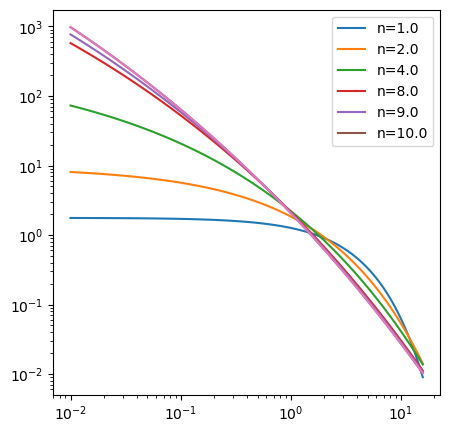

In [181]:
from pyLensLib.sersic_numba import sersic

# create a Sersic lens model instance
kwargs_sersic = {'zl': 0.5,
              'zs': 2.0,
              'sigma0': 250.0,
              'q': 1.0,
              'pa': 0.0,
              'r_eff': 1.0,
              'x1': 0.0,
              'x2': 0.0}

ss = sersic(**kwargs_sersic)


r = np.logspace(-2.0, 1.2, 100)

fig,ax = plt.subplots(1,1,figsize=(5,5))
for n in [1.0,2.0,4.0,8.0,9.0,10.0]:
    kwargs_sersic['n'] = n
    ss = sersic(**kwargs_sersic)
    sb = ss.brightness_profile(r)
    plt.plot(r,sb,label='n={}'.format(n))



ax.plot(r,sb)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

In [ ]:
import lmfit
rmin = 0.01
rmax = 10000.0

# initial setup
kwargs_fit = {'mass_in': 1e10, 'mass_fit': True, 'mass_min': 1e8, 'mass_max': 1e17,
              'conc_in': 8.0, 'conc_fit': True, 'conc_min': 0.001, 'conc_max': 1000.0,
              'flux_in': 1.0, 'flux_fit': True,'flux_min': 1e-2, 'flux_max': 1000.0,
              'rt_in': 0.1, 'rt_fit': True, 'rt_min': 100.0, 'rt_max': 10000.0}

def truncation(r,rt):
    return 1.0/(1.0+r**2/rt**2)**2

# 
def fit_comp_to_model(model,rmin,rmax,**kwargs_fit):
    r = np.logspace(np.log10(rmin),np.log10(rmax),100)
    p = lmfit.Parameters()
    p.add_many(('mass', np.log10(kwargs_fit['mass_in']), kwargs_fit['mass_fit'], 
                np.log10(kwargs_fit['mass_min']), np.log10(kwargs_fit['mass_max'])),
               ('conc', kwargs_fit['conc_in'], kwargs_fit['conc_fit'], 
                kwargs_fit['conc_min'], kwargs_fit['conc_max']),
               ('flux', np.log10(kwargs_fit['flux_in']), kwargs_fit['flux_fit'], 
                np.log10(kwargs_fit['flux_min']),  np.log10(kwargs_fit['flux_max'])),
               ('rt', np.log10(kwargs_fit['rt_in']), kwargs_fit['rt_fit'],
                np.log10(kwargs_fit['rt_min']), np.log10(kwargs_fit['rt_max'])))
    
    def cost_function(p,zl,n,re):
        v = p.valuesdict()
        ne = nfwell(co, zl=0.2, mass=10 ** v['mass'], conc=v['conc'])
        kwargs_sersic =  {'n': n,'re': re,'flux': 10**v['flux']}
        ss = sersic(**kwargs_sersic)
        if kwargs_fit['rt_fit']:
            conv = ne.nfwkappa(r)*truncation(r,10**v['rt']) + ss.brightness_profile(r)
        else:
            conv = ne.nfwkappa(r) + ss.brightness_profile(r)
        model_conv = model.surf_density(r)/ne.sigma_crit()
        cost = (np.log10(conv)-np.log10(model_conv))**2/np.log10(model_conv)**2
        return cost

    mini = lmfit.Minimizer(cost_function, p)
    mi = mini.minimize(method='Nelder',args=[zl,n,re])  # residual, p, method='Nelder')
    lmfit.report_fit(mi)

    return mi